In [3]:
from dyntex.MotionCloud import MotionCloud
from dyntex.DriftingGrating import DriftingGrating

import matplotlib.pyplot as plt 
from IPython.display import HTML
from matplotlib import animation
import matplotlib as mpl
mpl.rcParams['animation.writer']='pillow'
mpl.rcParams['animation.embed_limit']=1000

import torch as tch

import imageio as imio
import numpy as np
import pandas as pd

from scipy.optimize import minimize
import time

def to_numpy(x):
    return x.detach().cpu().numpy()

from scipy.special import i0, i1

ModuleNotFoundError: No module named 'torch'

In [ ]:
import shutil
import imageio.v2 as imageio
if shutil.which("ffmpeg") is None:
    raise RuntimeError("ffmpeg not found on PATH. Install or add it to PATH.")

In [ ]:
def write_mp4_safe(mp4_path, frames, fps=30, codec="libx264"):
    frames = np.asarray(frames)
    h, w = frames.shape[1], frames.shape[2]

    def prepare_frame(f):
        f = np.clip(f, 0, 255).astype(np.uint8)
        if f.ndim == 2:
            f = np.stack((f,)*3, axis=-1)
        elif f.shape[2] == 1:
            f = np.concatenate((f,)*3, axis=2)
        return f

    try:
        with imageio.get_writer(mp4_path, fps=fps, codec=codec, format="FFMPEG") as writer:
            for f in frames:
                writer.append_data(prepare_frame(f))
    except Exception as e:
        with imageio.get_writer(mp4_path, fps=fps, codec=codec, format="ffmpeg") as writer:
            for f in frames:
                writer.append_data(prepare_frame(f))

# USE THIS FOR GENERATION

In [ ]:
def linear_feature_profile_speed_per_frame(
    num_frames,
    start_frame,
    start_value,
    speed_per_frame,
    variation_duration_frames
):
    num_frames = int(num_frames)
    start_frame = int(start_frame)
    variation_duration_frames =int(variation_duration_frames)
    if variation_duration_frames<=0:
        raise ValueError("variation_duration_frames must be >0")
    if start_frame < 0:
        raise ValueError("start_frame must be >= 0")
    if start_frame + variation_duration_frames > num_frames:
        raise ValueError("Ramp exceeds total number of frames")

    feature_value = np.full(num_frames, float(start_value), dtype=float)

    # rampe linéaire
    t = np.arange(variation_duration_frames, dtype=float)
    ramp = float(start_value) + float(speed_per_frame)* t

    feature_value[start_frame : start_frame + variation_duration_frames] = ramp

    # valeur stationnaire finale
    final_value = ramp[-1]
    feature_value[start_frame + variation_duration_frames:] = final_value

    return feature_value


In [ ]:
def generate_nonstationary_MC_second_unit(num_frames, feature_name, feature_start_value, feature_speed,
                              variation_duration, save_npz=False, npz_path="stimulus.npz",
                              save_mp4=False, mp4_path="stimulus.mp4"):
    
    params = {"sf":4.0,"sf_sig":1.0,"th":0.0,"th_sig":5.0,"tf":5.0,"speed_vec":tch.tensor([0.0, 0.0]),"speed_sig":140.0,"octa":1,
              "N":256,"frame_per_second":100, 
              "start_time":0.5,"time_dt": 0.1,
              "device": "cuda" if tch.cuda.is_available() else "cpu"}
    
    # Convertion time per sec in time per frame
    fps_native = int(params["frame_per_second"])
    variation_duration_frames = int(np.round(float(variation_duration)*fps_native))
    if variation_duration_frames <=0:
        raise ValueError("variation_duration (in seconds) is too small")
    if variation_duration_frames> num_frames:
        raise ValueError("variation_duration (in seconds) is longer than the number of frames")
    speed_per_frame = float(feature_speed)/float(fps_native)

    high = params["start_time"] + params["time_dt"]
    low = params["start_time"] - params["time_dt"]
    start_time_rdm_sec = np.random.uniform(low, high) 
    start_frame_rdm = round(start_time_rdm_sec*fps_native)
    #start_frame_rdm = 57
    # sécurisation :
    #start_frame_rdm = int(round(start_time_rdm_sec * fps_native))
    #max_start_frame = num_frames - variation_duration_frames
    #start_frame_rdm = np.clip(start_frame_rdm, 0, max_start_frame)
    print(start_frame_rdm)
    # profil temporel de la feature
    L = linear_feature_profile_speed_per_frame(num_frames=num_frames, start_frame=start_frame_rdm, start_value=feature_start_value, speed_per_frame=speed_per_frame, variation_duration_frames=variation_duration_frames)
    print(L)
    MC = MotionCloud(N=params["N"], frame_per_second=fps_native,
                     contrast=35, ave_lum=127.0,
                     over_samp=10, verbose=0)
    MC.set_grids()

    frames = tch.zeros((num_frames, params["N"], params["N"]), dtype=tch.float32, device=params["device"])
    for i, value in enumerate(L):
        if feature_name == "sf":
            MC.bandpass_kernel(value, params["sf_sig"], params["th"], params["th_sig"],params["tf"],params["speed_vec"], params["octa"])
        elif feature_name == "th":
            MC.bandpass_kernel(params["sf"], params["sf_sig"], value, params["th_sig"], params["tf"], params["speed_vec"], params["octa"])
        else:
            raise ValueError("feature_name must be 'sf' or 'th'")
        frame = MC.get_frame(adjust=True)
        frames[i] = frame

    if isinstance(frames, tch.Tensor):       # Convertion numpy
        frames = frames.detach().cpu().numpy() 

    if save_npz:
        np.savez(npz_path, frames=frames, feature_name=feature_name, profile=L, fps=fps_native)

    if save_mp4:
        write_mp4_safe(mp4_path, frames)

    return frames


In [ ]:
A = generate_nonstationary_MC_second_unit(num_frames=200, feature_name="th", feature_start_value=0.0, feature_speed=50.0,
                              variation_duration=0.5, save_npz=True, npz_path="demo_code.npz",
                              save_mp4=True, mp4_path="demo_code.mp4")

41
[ 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5  7.
  7.5  8.   8.5  9.   9.5 10.  10.5 11.  11.5 12.  12.5 13.  13.5 14.
 14.5 15.  15.5 16.  16.5 17.  17.5 18.  18.5 19.  19.5 20.  20.5 21.
 21.5 22.  22.5 23.  23.5 24.  24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5
 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5
 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5
 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5
 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5
 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5
 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5
 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5
 24.5 24.

In [ ]:
A = generate_nonstationary_MC_second_unit(num_frames=200, feature_name="th", feature_start_value=0.0, feature_speed=50.0,
                              variation_duration=0.1, save_npz=False, npz_path="demo_code.npz",
                              save_mp4=True, mp4_path="blablabla2.mp4")

55
[0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5
 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5
 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5
 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5
 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5
 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5
 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5
 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5
 4.5 4.5]


In [ ]:
generate_nonstationary_MC_second_unit(num_frames=200, feature_name="sf", feature_start_value=3.0, feature_speed=4.0,
                              variation_duration=0.5, save_npz=True, npz_path="demo_code2.npz",
                              save_mp4=False, mp4_path="presentation.mp4")

57
[3.   3.   3.   3.   3.   3.   3.   3.   3.   3.   3.   3.   3.   3.
 3.   3.   3.   3.   3.   3.   3.   3.   3.   3.   3.   3.   3.   3.
 3.   3.   3.   3.   3.   3.   3.   3.   3.   3.   3.   3.   3.   3.
 3.   3.   3.   3.   3.   3.   3.   3.   3.   3.   3.   3.   3.   3.
 3.   3.   3.04 3.08 3.12 3.16 3.2  3.24 3.28 3.32 3.36 3.4  3.44 3.48
 3.52 3.56 3.6  3.64 3.68 3.72 3.76 3.8  3.84 3.88 3.92 3.96 4.   4.04
 4.08 4.12 4.16 4.2  4.24 4.28 4.32 4.36 4.4  4.44 4.48 4.52 4.56 4.6
 4.64 4.68 4.72 4.76 4.8  4.84 4.88 4.92 4.96 4.96 4.96 4.96 4.96 4.96
 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96
 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96
 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96
 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96
 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96
 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96 4.96
 4.96 4.96 4

array([[[ 99.39793 , 106.185936, 120.14997 , ..., 121.958435,
         112.05443 , 102.40609 ],
        [ 99.87909 , 106.82717 , 120.911865, ..., 122.5806  ,
         112.59713 , 102.845   ],
        [100.403   , 107.54988 , 121.725784, ..., 122.96856 ,
         112.964874, 103.222595],
        ...,
        [ 98.168236, 104.774796, 118.260635, ..., 118.70112 ,
         109.334885, 100.6516  ],
        [ 98.548706, 105.16106 , 118.81822 , ..., 120.01186 ,
         110.42253 , 101.31427 ],
        [ 98.95624 , 105.6304  , 119.449646, ..., 121.10079 ,
         111.33011 , 101.89784 ]],

       [[ 82.91867 ,  90.11101 , 104.785774, ..., 109.82408 ,
          96.6292  ,  85.857056],
        [ 84.18735 ,  91.67497 , 106.18788 , ..., 109.6848  ,
          96.83831 ,  86.57793 ],
        [ 85.45131 ,  93.2632  , 107.6069  , ..., 109.36043 ,
          96.900604,  87.225784],
        ...,
        [ 79.11665 ,  85.68883 , 100.831665, ..., 109.08853 ,
          95.03825 ,  83.1978  ],
        [ 80

# Exemple chargement d'une texture

In [ ]:
num_frames=200
feature_name="th"
feature_start_value=0.0
feature_speed=50.0
variation_duration=0.5
params = {"sf":4.0,"sf_sig":1.0,"th":0.0,"th_sig":5.0,"tf":5.0,"speed_vec":tch.tensor([0.0, 0.0]),"speed_sig":140.0,"octa":1,
              "N":256,"frame_per_second":100, 
              "start_time":0.5,"time_dt": 0.1,
              "device": "cuda" if tch.cuda.is_available() else "cpu"}
    
# Convertion time per sec in time per frame
fps_native = int(params["frame_per_second"])
variation_duration_frames = int(np.round(float(variation_duration)*fps_native))
speed_per_frame = float(feature_speed)/float(fps_native)

high = params["start_time"] + params["time_dt"]
low = params["start_time"] - params["time_dt"]
start_time_rdm_sec = np.random.uniform(low, high) 
start_frame_rdm = 57
    # sécurisation :
    #start_frame_rdm = int(round(start_time_rdm_sec * fps_native))
    #max_start_frame = num_frames - variation_duration_frames
    #start_frame_rdm = np.clip(start_frame_rdm, 0, max_start_frame)

    # profil temporel de la feature
L = linear_feature_profile_speed_per_frame(num_frames=num_frames, start_frame=start_frame_rdm, start_value=feature_start_value, speed_per_frame=speed_per_frame, variation_duration_frames=variation_duration_frames)

MC = MotionCloud(N=params["N"], frame_per_second=fps_native,
                     contrast=35, ave_lum=127.0,
                     over_samp=10, verbose=0)
MC.set_grids()

frames = tch.zeros((num_frames, params["N"], params["N"]), dtype=tch.float32, device=params["device"])
for i, value in enumerate(L):
    if feature_name == "sf":
        MC.bandpass_kernel(value, params["sf_sig"], params["th"], params["th_sig"],params["tf"],params["speed_vec"], params["octa"])
    elif feature_name == "th":
        MC.bandpass_kernel(params["sf"], params["sf_sig"], value, params["th_sig"], params["tf"], params["speed_vec"], params["octa"])

    frame = MC.get_frame(adjust=True)
    frames[i] = frame

In [ ]:
N = 256
# Estimation de theta_0
fx = tch.fft.fftshift(tch.fft.fftfreq(N)) * N
fy = fx.clone()
FX, FY = tch.meshgrid(fx, fy, indexing='xy')
theta = tch.atan2(FY, FX)
rho = tch.sqrt(FX**2 + FY**2)
theta[:N//2,:] += np.pi
theta=theta.flatten().cpu().numpy() 
est = 0
estimates_deg = []

for t in range(num_frames):
    frame=frames[t]
    F=tch.fft.fft2(frame-frame.mean(),norm='forward')
    F = tch.fft.fftshift(F, dim=(0, 1))
    psd = (tch.abs(F) ** 2).flatten().cpu().numpy()
    
    est = np.mod(1/2*np.angle(np.sum(psd * np.exp(1j*theta*2)) / np.sum(psd)),np.pi)
    estimates_deg.append(est*180/np.pi)
estimates_deg = np.array(estimates_deg)
print(L)
print(estimates_deg)

[ 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.
  6.5  7.   7.5  8.   8.5  9.   9.5 10.  10.5 11.  11.5 12.  12.5 13.
 13.5 14.  14.5 15.  15.5 16.  16.5 17.  17.5 18.  18.5 19.  19.5 20.
 20.5 21.  21.5 22.  22.5 23.  23.5 24.  24.5 24.5 24.5 24.5 24.5 24.5
 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5
 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5
 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5
 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5
 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5
 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5 24.5
 24.5 24.5 24

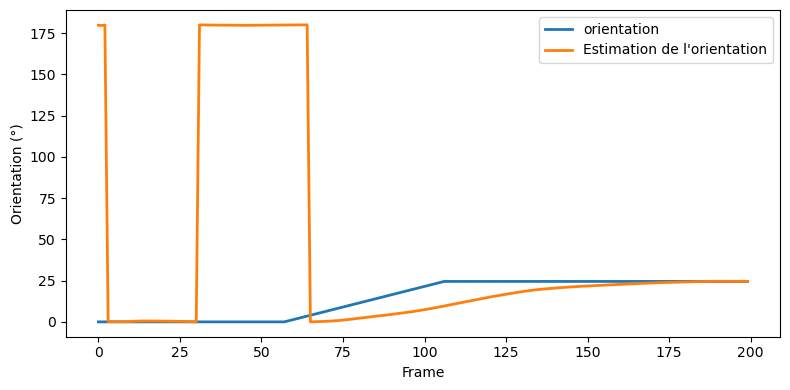

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(L, label="orientation", lw=2)
plt.plot(np.roll(estimates_deg,0), label= "Estimation de l'orientation", lw=2)
plt.xlabel("Frame")
plt.ylabel("Orientation (°)")
plt.legend()
#plt.title("Estimation de theta en temps réel")
plt.tight_layout()
plt.show()

In [ ]:
def generate_nonstationary_MC_second_unit(num_frames, feature_name, feature_start_value, feature_speed,
                              variation_duration, save_npz=False, npz_path="stimulus.npz",
                              save_mp4=False, mp4_path="stimulus.mp4"):
    
    params = {"sf":4.0,"sf_sig":1.0,"th":0.0,"th_sig":5.0,"tf":5.0,"speed_vec":tch.tensor([0.0, 0.0]),"speed_sig":140.0,"octa":1,
              "N":256,"frame_per_second":100, 
              "start_time":0.5,"time_dt": 0.1,
              "device": "cuda" if tch.cuda.is_available() else "cpu"}
    
    # Convertion time per sec in time per frame
    fps_native = int(params["frame_per_second"])
    variation_duration_frames = int(np.round(float(variation_duration)*fps_native))
    if variation_duration_frames <=0:
        raise ValueError("variation_duration (in seconds) is too small")
    if variation_duration_frames> num_frames:
        raise ValueError("variation_duration (in seconds) is longer than the number of frames")
    speed_per_frame = float(feature_speed)/float(fps_native)

    high = params["start_time"] + params["time_dt"]
    low = params["start_time"] - params["time_dt"]
    start_time_rdm_sec = np.random.uniform(low, high) 
    start_frame_rdm = round(start_time_rdm_sec*fps_native)
    #start_frame_rdm = 57
    # sécurisation :
    #start_frame_rdm = int(round(start_time_rdm_sec * fps_native))
    #max_start_frame = num_frames - variation_duration_frames
    #start_frame_rdm = np.clip(start_frame_rdm, 0, max_start_frame)
    print(start_frame_rdm)
    # profil temporel de la feature
    L = linear_feature_profile_speed_per_frame(num_frames=num_frames, start_frame=start_frame_rdm, start_value=feature_start_value, speed_per_frame=speed_per_frame, variation_duration_frames=variation_duration_frames)
    print(L)
    MC = MotionCloud(N=params["N"], frame_per_second=fps_native,
                     contrast=35, ave_lum=127.0,
                     over_samp=10, verbose=0)
    MC.set_grids()

    frames = tch.zeros((num_frames, params["N"], params["N"]), dtype=tch.float32, device=params["device"])
    for i, value in enumerate(L):
        if feature_name == "sf":
            MC.bandpass_kernel(value, params["sf_sig"], params["th"], params["th_sig"],params["tf"],params["speed_vec"], params["octa"])
        elif feature_name == "th":
            MC.bandpass_kernel(params["sf"], params["sf_sig"], value, params["th_sig"], params["tf"], params["speed_vec"], params["octa"])
        else:
            raise ValueError("feature_name must be 'sf' or 'th'")
        frame = MC.get_frame(adjust=True)
        frames[i] = frame

    if isinstance(frames, tch.Tensor):       # Convertion numpy
        frames = frames.detach().cpu().numpy() 

    if save_npz:
        np.savez(npz_path, frames=frames, feature_name=feature_name, profile=L, fps=fps_native, start_frame_rdm=start_frame_rdm)

    if save_mp4:
        write_mp4_safe(mp4_path, frames)

    return frames


In [ ]:
A = generate_nonstationary_MC_second_unit(num_frames=200, feature_name="th", feature_start_value=40.0, feature_speed=50.0,
                              variation_duration=0.5, save_npz=True, npz_path="test_alpha.npz",
                              save_mp4=False, mp4_path="demo_code.mp4")

40
[40.  40.  40.  40.  40.  40.  40.  40.  40.  40.  40.  40.  40.  40.
 40.  40.  40.  40.  40.  40.  40.  40.  40.  40.  40.  40.  40.  40.
 40.  40.  40.  40.  40.  40.  40.  40.  40.  40.  40.  40.  40.  40.5
 41.  41.5 42.  42.5 43.  43.5 44.  44.5 45.  45.5 46.  46.5 47.  47.5
 48.  48.5 49.  49.5 50.  50.5 51.  51.5 52.  52.5 53.  53.5 54.  54.5
 55.  55.5 56.  56.5 57.  57.5 58.  58.5 59.  59.5 60.  60.5 61.  61.5
 62.  62.5 63.  63.5 64.  64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5
 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5
 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5
 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5
 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5
 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5
 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5
 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5 64.5
 64.5

In [ ]:
npz_path = "/Users/cesar/Desktop/dyntex-master/python/Test2_dyn.npz"
data = np.load(npz_path)

In [ ]:
print(data)

NpzFile '/Users/cesar/Desktop/dyntex-master/python/Test2_dyn.npz' with keys: frames, feature_name, profile, time_max_frame, fps


# USE THIS FOR GENERATION

In [ ]:
def generate_nonstationary_MC_second_unit(
    stimulus_duration_s,
    feature_name,
    feature_start_value,
    feature_speed,
    variation_duration,
    save_npz=False,
    npz_path="stimulus.npz",
    save_mp4=False,
    mp4_path="stimulus.mp4"
):

    params = {
        "sf": 5.0,
        "sf_sig": 1.0, # sf bandwidth, to change
        "th": 0.0,
        "th_sig": 5.0, # th bandwidth
        "tf": 5.0,
        "speed_vec": tch.tensor([0.0, 0.0]),
        "speed_sig": 140.0,
        "octa": 1,
        "N": 256,
        "frame_per_second": 100,
        "device": "cuda" if tch.cuda.is_available() else "cpu"
    }

    fps_native = int(params["frame_per_second"])

    # Durée totale -> nombre de frames
    num_frames = int(np.round(float(stimulus_duration_s) * fps_native))

    # variation_duration reste en secondes
    variation_duration_frames = int(np.round(float(variation_duration) * fps_native))
    if variation_duration_frames <= 0:
        raise ValueError("variation_duration (in seconds) is too small")
    if variation_duration_frames > num_frames:
        raise ValueError("variation_duration is longer than stimulus")

    speed_per_frame = float(feature_speed) / float(fps_native)

    # Début du changement fixé à 2650 ms
    start_time = 3000
    start_frame = int(np.round(start_time * fps_native / 1000.0))

   # time_max : moment à partir duquel il reste encore 3130 ms
    total_duration_ms = float(stimulus_duration_s) * 1000.0
    time_max_ms = total_duration_ms - 3130.0

    if time_max_ms < 0:
        raise ValueError("stimulus_duration_s is shorter than 3130 ms, so time_max_ms is negative")

    # Frame associée à time_max_ms
    time_max_frame = int(np.round(time_max_ms * fps_native / 1000.0))
    time_max_frame = int(np.clip(time_max_frame, 0, num_frames - 1))


    # Profil temporel
    L = linear_feature_profile_speed_per_frame(
        num_frames=num_frames,
        start_frame=start_frame,
        start_value=feature_start_value,
        speed_per_frame=speed_per_frame,
        variation_duration_frames=variation_duration_frames
    )

    print(L)
    feature_end_value = L[start_frame + variation_duration_frames - 1]
    print(feature_end_value)
    MC = MotionCloud(
        N=params["N"],
        frame_per_second=fps_native,
        contrast=35,
        ave_lum=127.0,
        over_samp=10,
        verbose=0
    )
    MC.set_grids()

    frames = tch.zeros(
        (num_frames, params["N"], params["N"]),
        dtype=tch.float32,
        device=params["device"]
    )

    for i, value in enumerate(L):
        if feature_name == "sf":
            MC.bandpass_kernel(
                value, params["sf_sig"], params["th"], params["th_sig"],
                params["tf"], params["speed_vec"], params["octa"]
            )
        elif feature_name == "th":
            MC.bandpass_kernel(
                params["sf"], params["sf_sig"], value, params["th_sig"],
                params["tf"], params["speed_vec"], params["octa"]
            )
        else:
            raise ValueError("feature_name must be 'sf' or 'th'")

        frame = MC.get_frame(adjust=True)
        frames[i] = frame

    if isinstance(frames, tch.Tensor):
        frames = frames.detach().cpu().numpy()

    if save_npz:
        np.savez(
            npz_path,
            frames=frames,
            feature_name=feature_name,
            profile=L,
            time_max_frame=time_max_frame,
            fps=fps_native,
            feature_start_value = feature_start_value,
            feature_end_value = feature_end_value 
        )

    if save_mp4:
        write_mp4_safe(mp4_path, frames)
    
    print(time_max_frame)

    return frames, time_max_ms, time_max_frame

In [ ]:
A = generate_nonstationary_MC_second_unit(stimulus_duration_s=4.0, feature_name="th", feature_start_value=0.0, feature_speed=15.0,
                              variation_duration=0.2, save_npz=True, npz_path="dynamic_stimulus_orientation_10.npz",
                              save_mp4=False, mp4_path="Test3_dyn.mp4")

[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0. 

In [ ]:
for speed in np.arange(15, 55, 2.0): 
    print(-speed)

NameError: name 'np' is not defined

In [ ]:
for speed in np.arange(15, 55, 2.0):  
    speed_rounded = round(-speed, 2) 
    A = generate_nonstationary_MC_second_unit(
        stimulus_duration_s=4.0,
        feature_name="th",
        feature_start_value=0.0,
        feature_speed=speed_rounded,
        variation_duration=0.2,
        save_npz=True,
        npz_path=f"dynamic_stimulus_orientation_{speed_rounded}.npz",
        save_mp4=False,
        mp4_path=f"stimulus_orientation_{speed_rounded}.mp4"
    )

[ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.  

### modified starting value

In [ ]:
B =generate_nonstationary_MC_second_unit(stimulus_duration_s=4.0, feature_name="sf", feature_start_value=5.0, feature_speed=-6.0,
                              variation_duration=0.2, save_npz=False, npz_path="dynamic_stimulus_fspatial_-3.npz",
                              save_mp4=False, mp4_path="SF_test.mp4")

NameError: name 'generate_nonstationary_MC_second_unit' is not defined

In [ ]:
for k in np.arange(30, 60, 5.0):  
    print(k)

30.0
35.0
40.0
45.0
50.0
55.0


In [ ]:
for speed in np.arange(16, 9, -1.0):  
    speed_rounded = round(-speed, 2) 
    B = generate_nonstationary_MC_second_unit(
        stimulus_duration_s=4.0,
        feature_name="sf",
        feature_start_value=6.0,
        feature_speed=speed_rounded,
        variation_duration=0.2,
        save_npz=True,
        npz_path=f"dynamic_stimulus_spatial_frequency_{speed_rounded}.npz",
        save_mp4=False,
        mp4_path=f"stimulus_orientation_{speed_rounded}.mp4")

[6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.
 6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.
 6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.
 6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.
 6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.
 6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.
 6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.
 6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.
 6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.
 6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.
 6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.
 6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.
 6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.
 6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.
 6.   6.   6.   6.   6.   6.   6. 

In [ ]:
for k in np.arange(10,20,5):
    print(k)

10
15
